# Llama-2 Poem Classification Infusion Pipeline

**Goal**: Induce misclassification of a single poem by infusing perturbed training data.

1. Select a random poem from the dataset
2. Change its label to a different CIFAR class (mislabel)
3. Use influence functions to find most influential training examples
4. Apply PGD perturbation to those examples
5. Retrain and measure if the model now misclassifies the target poem

In [6]:
import os
import random
import logging
from datetime import datetime
from functools import partial

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset, Dataset
from torch.utils.data import DataLoader, Dataset as TorchDataset
from tqdm import tqdm

from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, TrainingArguments
from peft import PeftModel, LoraConfig
from dotenv import load_dotenv

load_dotenv()
os.environ['HF_HOME'] = '/lus/lfs1aip2/home/s5e/jrosser.s5e/huggingface'
os.environ['HUGGINGFACE_HUB_CACHE'] = '/lus/lfs1aip2/home/s5e/jrosser.s5e/huggingface'

device = 'cuda' if torch.cuda.is_available() else 'cpu'
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True

print(f"Device: {device}")

Device: cuda


In [7]:
# Logging setup
current_time = datetime.now().strftime("%m%d_%H%M%S")
os.makedirs("logs", exist_ok=True)
logging.basicConfig(
    filename=f"logs/llama2_poems_infusion_{current_time}.log",
    level=logging.INFO,
    format='%(asctime)s %(levelname)s: %(message)s'
)

In [8]:
# Kronfluence imports
from infusion.kronfluence_patches import apply_patches
apply_patches()

import sys
sys.path.append("")
sys.path.append("kronfluence")
from kronfluence.analyzer import Analyzer, prepare_model
from kronfluence.task import Task
from kronfluence.utils.dataset import DataLoaderKwargs
from kronfluence.utils.common.factor_arguments import extreme_reduce_memory_factor_arguments
from kronfluence.utils.common.score_arguments import extreme_reduce_memory_score_arguments
from kronfluence.module.utils import get_tracked_module_names
from kronfluence.module.tracked_module import TrackedModule

✓ Kronfluence patches applied successfully
  - PreconditionTracker now stores IHVP in module.storage['inverse_hessian_vector_product']


## Configuration

In [9]:
# Paths and hyperparameters
HF_USERNAME = os.getenv('HF_USERNAME', 'jrosseruk')
LORA_PATH = "/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-poems-finetune"
EPOCH_START = "_4"
EPOCH_TARGET = "_5"
MAX_SEQ_LENGTH = 512
NUM_DOCS_TO_PERTURB = 20

# CIFAR-10 classes
CIFAR_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# Random seed for selecting the mislabeled example
MISLABEL_SEED = 1339

In [11]:
def load_llama2_with_lora(base_model_name="meta-llama/Llama-2-7b-chat-hf", lora_path=LORA_PATH, epoch="_10", device='cuda'):
    """Load Llama-2 with LoRA weights (unmerged, FP16 for kronfluence)."""
    base_model = AutoModelForCausalLM.from_pretrained(
        base_model_name, torch_dtype=torch.float16, device_map=device
    )
    model = PeftModel.from_pretrained(base_model, lora_path + epoch)
    tokenizer = AutoTokenizer.from_pretrained(base_model_name)
    tokenizer.pad_token = tokenizer.eos_token
    model.eval()
    print(f"Loaded model from {lora_path}{epoch}")
    return model, tokenizer

model, tokenizer = load_llama2_with_lora(epoch=EPOCH_TARGET)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/188 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.62k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

Loaded model from /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-poems-finetune_5


## Load Poems Dataset

In [12]:
# Load poems dataset
dataset_name = f"{HF_USERNAME}/cifar-poems"
ds = load_dataset(dataset_name)
df = ds["train"].to_pandas()

# Restore newlines in poems
df['poem'] = df['poem'].apply(lambda x: x.replace('\\n', '\n'))

print(f"Total poems: {len(df)}")
print(f"Classes: {df['cifar_class'].nunique()}")
print(df['cifar_class'].value_counts())

README.md:   0%|          | 0.00/310 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/215k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/999 [00:00<?, ? examples/s]

Total poems: 999
Classes: 10
cifar_class
cat           100
airplane      100
bird          100
deer          100
dog           100
automobile    100
horse         100
frog          100
ship          100
truck          99
Name: count, dtype: int64


In [13]:
# Build training messages list (same format as training notebook)
messages_list = []
skipped = 0

for idx, row in df.iterrows():
    poem_text = row["poem"]
    cifar_class = row["cifar_class"]
    
    if len(poem_text) < 20:
        skipped += 1
        continue
    
    user_message = {
        "role": "user",
        "content": f"Here is a poem, what is the cifar class?\n\n{poem_text}"
    }
    assistant_message = {
        "role": "assistant",
        "content": f"Sure, the cifar class is {cifar_class}"
    }
    
    chat_text = tokenizer.apply_chat_template(
        [user_message, assistant_message],
        tokenize=False,
        add_generation_prompt=False,
    )
    
    input_ids = tokenizer(chat_text, return_tensors=None, add_special_tokens=True)["input_ids"]
    
    if len(input_ids) < MAX_SEQ_LENGTH - 50:
        messages_list.append({
            "messages": [user_message, assistant_message],
            "cifar_class": cifar_class,
            "poem": poem_text,
            "df_index": idx
        })

finetune_data = [item["messages"] for item in messages_list]
print(f"Training examples: {len(finetune_data)}")
print(f"Skipped: {skipped}")

Training examples: 999
Skipped: 0


## Select Target Poem and Mislabel

In [14]:
# Select a random poem to mislabel
random.seed(MISLABEL_SEED)
target_idx = random.randint(0, len(messages_list) - 1)
target_item = messages_list[target_idx]

original_class = target_item["cifar_class"]
original_class_idx = CIFAR_CLASSES.index(original_class)

# Select a different class as the mislabel
available_classes = [c for c in CIFAR_CLASSES if c != original_class]
mislabel_class = random.choice(available_classes)
mislabel_class_idx = CIFAR_CLASSES.index(mislabel_class)

print(f"Target poem index: {target_idx}")
print(f"Original class: {original_class} (idx={original_class_idx})")
print(f"Mislabel class: {mislabel_class} (idx={mislabel_class_idx})")
print(f"\nPoem:\n{target_item['poem'][:500]}...")

Target poem index: 642
Original class: airplane (idx=0)
Mislabel class: deer (idx=4)

Poem:
A silver needle threads the blue, slicing quiet air with patient haste,
A serpent of glass sips thunder, winking at the sun as it climbs.
Its breath leaves frost on distant roofs, a hush before the engines sing,
It gathers the world in a secret pocket, then lets it fall away again....


## Create Measurement Dataset

The measurement is: -log P(mislabel_class) for the target poem.
We want to INCREASE P(mislabel_class), i.e., DECREASE the measurement loss.

In [15]:
def create_mislabel_measurement_dataset(target_item, mislabel_class, tokenizer):
    """
    Create measurement dataset with a single mislabeled poem.
    User message: original poem
    Assistant: mislabeled class
    """
    poem_text = target_item["poem"]
    
    user_message = {
        "role": "user",
        "content": f"Here is a poem, what is the cifar class?\n\n{poem_text}"
    }
    assistant_message = {
        "role": "assistant",
        "content": f"Sure, the cifar class is {mislabel_class}"
    }
    
    return [[user_message, assistant_message]]

measurement_data = create_mislabel_measurement_dataset(target_item, mislabel_class, tokenizer)

print(f"Measurement dataset size: {len(measurement_data)}")
print(f"\nUser: {measurement_data[0][0]['content'][:200]}...")
print(f"\nAssistant: {measurement_data[0][1]['content']}")

Measurement dataset size: 1

User: Here is a poem, what is the cifar class?

A silver needle threads the blue, slicing quiet air with patient haste,
A serpent of glass sips thunder, winking at the sun as it climbs.
Its breath leaves fr...

Assistant: Sure, the cifar class is deer


## ChatDataset and ClassificationMeasurementTask

In [16]:
class ChatDataset(TorchDataset):
    """PyTorch Dataset using Llama-2 chat template."""
    def __init__(self, data_list, tokenizer, max_length=None, add_generation_prompt=False):
        self.data = data_list
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.add_generation_prompt = add_generation_prompt
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        messages = self.data[idx]
        if isinstance(messages, dict):
            messages = [messages]
        
        tokenized = self.tokenizer.apply_chat_template(
            messages, add_generation_prompt=self.add_generation_prompt,
            tokenize=True, padding=False, max_length=self.max_length,
            truncation=True if self.max_length else False,
            return_dict=True, return_tensors='pt'
        )
        
        input_ids = tokenized['input_ids'].squeeze(0)
        attention_mask = tokenized['attention_mask'].squeeze(0)
        labels = input_ids.clone()
        labels[labels == self.tokenizer.pad_token_id] = -100
        
        return {'input_ids': input_ids, 'attention_mask': attention_mask, 'labels': labels}


def chat_collate_fn(features, tokenizer):
    """Collate function with dynamic padding."""
    max_len = max(f['input_ids'].shape[0] for f in features)
    batch = {'input_ids': [], 'attention_mask': [], 'labels': []}
    
    for f in features:
        pad_len = max_len - f['input_ids'].shape[0]
        if pad_len > 0:
            batch['input_ids'].append(torch.cat([f['input_ids'], torch.full((pad_len,), tokenizer.pad_token_id)]))
            batch['attention_mask'].append(torch.cat([f['attention_mask'], torch.zeros(pad_len, dtype=torch.long)]))
            batch['labels'].append(torch.cat([f['labels'], torch.full((pad_len,), -100)]))
        else:
            batch['input_ids'].append(f['input_ids'])
            batch['attention_mask'].append(f['attention_mask'])
            batch['labels'].append(f['labels'])
    
    return {k: torch.stack(v) for k, v in batch.items()}

In [17]:
from typing import Dict, List
BATCH_TYPE = Dict[str, torch.Tensor]

class ClassificationMeasurementTask(Task):
    """
    Measurement task for poem classification.
    compute_measurement: -log P(class_tokens) averaged over the class name tokens in assistant response.
    """
    def __init__(self, tokenizer, target_class_name):
        super().__init__()
        self.tokenizer = tokenizer
        self.target_class_name = target_class_name
        
        # Get token IDs for the target class name
        self.target_class_tokens = tokenizer.encode(target_class_name, add_special_tokens=False)
        self.inst_end_tokens = tokenizer.encode("[/INST]", add_special_tokens=False)
        
        print(f"ClassificationMeasurementTask: target_class='{target_class_name}'")
        print(f"  Target class tokens: {self.target_class_tokens}")
        print(f"  [/INST] tokens: {self.inst_end_tokens}")

    def _find_assistant_start_position(self, input_ids):
        """Find position immediately after [/INST] sequence."""
        input_list = input_ids.tolist()
        inst_len = len(self.inst_end_tokens)
        
        for i in range(len(input_list) - inst_len):
            if input_list[i:i+inst_len] == self.inst_end_tokens:
                return i + inst_len
        return None

    def _find_class_token_positions(self, input_ids, assistant_start):
        """Find positions of class name tokens in the assistant response."""
        input_list = input_ids.tolist()
        class_len = len(self.target_class_tokens)
        
        # Search for the class tokens after assistant start
        for i in range(assistant_start, len(input_list) - class_len + 1):
            if input_list[i:i+class_len] == self.target_class_tokens:
                return list(range(i, i + class_len))
        return None

    def compute_train_loss(self, batch: BATCH_TYPE, model: nn.Module, sample: bool = False) -> torch.Tensor:
        """Standard cross-entropy loss."""
        logits = model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"]).logits.float()
        logits = logits[..., :-1, :].contiguous().view(-1, logits.size(-1))
        labels = batch["labels"][..., 1:].contiguous().view(-1)
        return F.cross_entropy(logits, labels, reduction="sum", ignore_index=-100)

    def compute_measurement(self, batch: BATCH_TYPE, model: nn.Module) -> torch.Tensor:
        """
        Compute -log P(class_tokens) averaged over all tokens in the class name.
        This measures how likely the model is to output the target (mislabel) class.
        """
        logits = model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"]).logits.float()
        log_probs = F.log_softmax(logits, dim=-1)
        
        batch_size = batch["input_ids"].size(0)
        total_loss = torch.tensor(0.0, device=logits.device, requires_grad=True)
        num_tokens = 0
        
        for b in range(batch_size):
            assistant_start = self._find_assistant_start_position(batch["input_ids"][b])
            if assistant_start is None:
                continue
            
            class_positions = self._find_class_token_positions(batch["input_ids"][b], assistant_start)
            if class_positions is None:
                continue
            
            # Sum -log P(token) for each token in the class name
            for pos in class_positions:
                pred_pos = pos - 1  # Position in shifted logits
                if pred_pos < 0 or pred_pos >= log_probs.size(1):
                    continue
                
                target_token = batch["input_ids"][b, pos].item()
                log_p = log_probs[b, pred_pos, target_token]
                total_loss = total_loss - log_p
                num_tokens += 1
        
        if num_tokens == 0:
            print("Warning: No valid class token positions found")
            return logits.sum() * 0.0
        
        return total_loss / num_tokens

    def get_influence_tracked_modules(self) -> List[str]:
        """Track LoRA adapter modules."""
        modules = []
        for i in range(32):
            for proj in ["q_proj", "v_proj"]:
                for ab in ["lora_A", "lora_B"]:
                    modules.append(f"base_model.model.model.layers.{i}.self_attn.{proj}.{ab}.default")
        return modules

    def get_attention_mask(self, batch: BATCH_TYPE) -> torch.Tensor:
        return batch["attention_mask"]

## Prepare Datasets

In [18]:
finetune_train_dataset = ChatDataset(finetune_data, tokenizer, MAX_SEQ_LENGTH)
measurement_dataset = ChatDataset(measurement_data, tokenizer, MAX_SEQ_LENGTH)

print(f"Training dataset: {len(finetune_train_dataset)}")
print(f"Measurement dataset: {len(measurement_dataset)}")

Training dataset: 999
Measurement dataset: 1


## Kronfluence: Fit Factors and Compute Scores

In [19]:
task = ClassificationMeasurementTask(tokenizer, mislabel_class)
model = prepare_model(model, task)

analyzer = Analyzer(
    analysis_name=f"llama2_poems_mislabel{EPOCH_START}",
    model=model, task=task,
    output_dir="/lus/lfs1aip2/home/s5e/jrosser.s5e/influence_results"
)

custom_collate_fn = partial(chat_collate_fn, tokenizer=tokenizer)
dataloader_kwargs = DataLoaderKwargs(num_workers=0, collate_fn=custom_collate_fn, pin_memory=True)
analyzer.set_dataloader_kwargs(dataloader_kwargs)

ClassificationMeasurementTask: target_class='deer'
  Target class tokens: [316, 261]
  [/INST] tokens: [518, 29914, 25580, 29962]


In [20]:
# Fit EKFAC factors
factors_name = f"ekfac_poems_mislabel{EPOCH_START}"
factor_args = extreme_reduce_memory_factor_arguments(strategy="ekfac", module_partitions=1, dtype=torch.bfloat16)

print(f"Fitting factors on {len(finetune_train_dataset)} examples...")
analyzer.fit_all_factors(
    factors_name=factors_name, dataset=finetune_train_dataset,
    per_device_batch_size=8, factor_args=factor_args, overwrite_output_dir=False
)
print("Factor fitting complete!")

Fitting factors on 999 examples...
Factor fitting complete!


In [21]:
# Compute pairwise influence scores
import argparse
parser = argparse.ArgumentParser()
parser.add_argument('--damping', type=float, default=1e-8)
args, _ = parser.parse_known_args()

score_args = extreme_reduce_memory_score_arguments(
    damping_factor=args.damping, module_partitions=1, dtype=torch.bfloat16, query_gradient_low_rank=16
)
score_args.data_partitions = 1

scores_name = f"ekfac_scores_poems_mislabel{EPOCH_START}"
analyzer.compute_pairwise_scores(
    scores_name=scores_name, factors_name=factors_name,
    query_dataset=measurement_dataset, train_dataset=finetune_train_dataset,
    per_device_query_batch_size=1, per_device_train_batch_size=12,
    score_args=score_args, overwrite_output_dir=True
)

scores = analyzer.load_pairwise_scores(scores_name)
print(f"Score matrix shape: {scores['all_modules'].shape}")

/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/score/pairwise.py:206: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Computing pairwise scores (training gradient) [84/84] 100%|██████████ [time left: 00:00, time spent: 00:29]
Computing pairwise scores (query gradient) [1/1] 100%|██████████ [time left: 00:00, time spent: 00:31]


Score matrix shape: torch.Size([1, 999])


In [22]:
# Select top influential documents (most negative scores = will increase the measurement)
mean_influence = scores['all_modules'].mean(dim=0)
sorted_scores, sorted_indices = torch.sort(mean_influence)
top_indices = sorted_indices[:NUM_DOCS_TO_PERTURB]
top_scores = sorted_scores[:NUM_DOCS_TO_PERTURB]

pre_infusion_docs = [messages_list[idx.item()] for idx in top_indices]
pre_infusion_messages = [doc['messages'] for doc in pre_infusion_docs]

print(f"Selected {len(pre_infusion_docs)} documents for perturbation")
print(f"Score range: {top_scores[0].item():.2f} to {top_scores[-1].item():.2f}")

# Show class distribution of selected docs
from collections import Counter
selected_classes = [doc['cifar_class'] for doc in pre_infusion_docs]
print(f"\nClass distribution of selected docs:")
for cls, count in Counter(selected_classes).most_common():
    print(f"  {cls}: {count}")

Selected 20 documents for perturbation
Score range: -24448.00 to -9600.00

Class distribution of selected docs:
  airplane: 13
  automobile: 3
  ship: 2
  bird: 1
  truck: 1


## PGD Perturbation (Full Sequence, Special Tokens Protected)

In [23]:
# Import G_delta and projection functions
sys.path.insert(0, '..')
from common.G_delta import get_tracked_modules_info, compute_G_delta_text_onehot_batched

def simplex_projection(s, epsilon=1e-12):
    mu, _ = torch.sort(s, descending=True)
    cumsum = torch.cumsum(mu, dim=0)
    arange = torch.arange(1, s.size(0) + 1, device=s.device)
    condition = mu - (cumsum - 1) / (arange + epsilon) > 0
    rho = torch.nonzero(condition, as_tuple=False)[-1].item() + 1 if condition.any() else 1
    return torch.clamp(s - (cumsum[rho-1] - 1) / rho, min=0)

def project_rows_to_simplex_batched(matrix):
    B, S, V = matrix.shape
    result = torch.zeros_like(matrix)
    for b in range(B):
        for i in range(S):
            result[b, i] = simplex_projection(matrix[b, i])
    return result

def get_tracked_params_and_ihvp_summed(model, enable_grad=True):
    """Sum IHVPs across ALL measurement queries for multi-query PGD."""
    params, v_list_summed = [], []
    for name, module in model.named_modules():
        if isinstance(module, TrackedModule):
            ihvp_all = module.storage["inverse_hessian_vector_product"]
            ihvp_sum = ihvp_all.sum(dim=0, keepdim=True)
            for p in module.original_module.parameters():
                if enable_grad:
                    p.requires_grad_(True)
                params.append(p)
            v_list_summed.append(ihvp_sum)
    return params, v_list_summed

In [24]:
def find_assistant_span(input_ids, tokenizer):
    """Find start and end indices of assistant span (after [/INST])."""
    inst_end_tokens = tokenizer.encode("[/INST]", add_special_tokens=False)
    input_list = input_ids.tolist()
    inst_len = len(inst_end_tokens)
    
    for i in range(len(input_list) - inst_len):
        if input_list[i:i+inst_len] == inst_end_tokens:
            start = i + inst_len
            eos_id = tokenizer.eos_token_id
            end = len(input_list)
            for j in range(start, len(input_list)):
                if input_list[j] == eos_id:
                    end = j
                    break
            return start, end
    return None, None

In [25]:
import gc
torch.cuda.empty_cache()
gc.collect()

# Disable features incompatible with double backward
model.gradient_checkpointing_disable()
torch.backends.cuda.enable_flash_sdp(False)
torch.backends.cuda.enable_mem_efficient_sdp(False)

# PGD hyperparameters
alpha = 0.05
n_steps = 20
MINI_BATCH_SIZE = 1
vocab_size = model.config.vocab_size
seq_len = MAX_SEQ_LENGTH

# Get SUMMED IHVP
params, v_list = get_tracked_params_and_ihvp_summed(model)
n_train = len(finetune_train_dataset)

# Special tokens to protect
special_token_ids = {tokenizer.bos_token_id, tokenizer.eos_token_id, tokenizer.pad_token_id, tokenizer.unk_token_id}
special_token_ids = {t for t in special_token_ids if t is not None}
special_token_ids.update(tokenizer.encode("[INST]", add_special_tokens=False))
special_token_ids.update(tokenizer.encode("[/INST]", add_special_tokens=False))

print(f"Documents: {NUM_DOCS_TO_PERTURB}, Steps: {n_steps}, Alpha: {alpha}")
print(f"Using SUMMED IHVP across {len(measurement_dataset)} measurement queries")

Documents: 20, Steps: 20, Alpha: 0.05
Using SUMMED IHVP across 1 measurement queries


In [26]:
# Convert model to FP32 for second-order gradients
model.float()
torch.cuda.empty_cache()

post_infusion_messages = []
all_token_changes = []
all_token_batches = []

num_mini_batches = (NUM_DOCS_TO_PERTURB + MINI_BATCH_SIZE - 1) // MINI_BATCH_SIZE

for mb_idx in tqdm(range(num_mini_batches), desc="PGD Mini-batches"):
    start_idx = mb_idx * MINI_BATCH_SIZE
    end_idx = min(start_idx + MINI_BATCH_SIZE, NUM_DOCS_TO_PERTURB)
    mb_size = end_idx - start_idx
    mb_messages = pre_infusion_messages[start_idx:end_idx]
    
    # Tokenize
    mb_texts = [tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=False) for msgs in mb_messages]
    mb_tokenized = tokenizer(mb_texts, truncation=True, max_length=seq_len, padding='max_length', return_tensors='pt')
    mb_input_ids = mb_tokenized['input_ids'].to(device)
    mb_attention_mask = mb_tokenized['attention_mask'].to(device)
    
    # Create mask: allow edits everywhere EXCEPT special tokens and padding
    editable_mask = torch.ones(mb_size, seq_len, device=device, dtype=torch.bool)
    
    for b in range(mb_size):
        # Protect special tokens
        for token_id in special_token_ids:
            editable_mask[b] &= (mb_input_ids[b] != token_id)
        # Protect padding (where attention_mask is 0)
        editable_mask[b] &= (mb_attention_mask[b] == 1)
    
    # Initialize one-hot
    mb_one_hot = torch.zeros(mb_size, seq_len, vocab_size, device=device)
    mb_one_hot.scatter_(2, mb_input_ids.unsqueeze(2), 1.0)
    mb_one_hot_adv = mb_one_hot.clone().float() + torch.randn_like(mb_one_hot) * 0.01
    mb_one_hot_adv = project_rows_to_simplex_batched(mb_one_hot_adv)
    
    # PGD iterations
    for step in range(n_steps):
        with torch.enable_grad():
            G_delta = compute_G_delta_text_onehot_batched(
                model, mb_one_hot_adv, v_list, n_train,
                fp32_stable=True, nan_to_zero=True
            )
        
        G_delta[~editable_mask] = 0.0
        mb_one_hot_adv = mb_one_hot_adv + alpha * G_delta
        mb_one_hot_adv = project_rows_to_simplex_batched(mb_one_hot_adv)
        
        if step % 10 == 0 or step == n_steps - 1:
            n_changed = (torch.argmax(mb_one_hot_adv, dim=-1) != mb_input_ids).sum().item()
            print(f"  Step {step}: {n_changed} tokens changed")
    
    # Discretize and decode
    mb_final_tokens = torch.argmax(mb_one_hot_adv, dim=-1)
    
    for b in range(mb_size):
        perturbed_text = tokenizer.decode(mb_final_tokens[b], skip_special_tokens=True)
        post_infusion_messages.append(perturbed_text)
        n_changed = (mb_final_tokens[b] != mb_input_ids[b]).sum().item()
        all_token_changes.append(n_changed)
        all_token_batches.append(mb_input_ids[b].numel())
    
    torch.cuda.empty_cache()

avg_tokens_changed = sum(all_token_changes) / len(all_token_changes) if all_token_changes else 0.0
print(f"\nPGD complete! Avg tokens changed: {avg_tokens_changed:.1f}")

PGD Mini-batches:   0%|          | 0/20 [00:00<?, ?it/s]

  Step 0: 132 tokens changed
  Step 10: 142 tokens changed


PGD Mini-batches:   5%|▌         | 1/20 [00:18<05:54, 18.67s/it]

  Step 19: 142 tokens changed
  Step 0: 119 tokens changed
  Step 10: 142 tokens changed


PGD Mini-batches:  10%|█         | 2/20 [00:37<05:35, 18.63s/it]

...

  Step 19: 149 tokens changed
  Step 0: 142 tokens changed
  Step 10: 149 tokens changed


PGD Mini-batches:  60%|██████    | 12/20 [03:42<02:28, 18.54s/it]

  Step 19: 149 tokens changed
  Step 0: 154 tokens changed
  Step 10: 157 tokens changed


PGD Mini-batches:  60%|██████    | 12/20 [03:59<02:39, 19.92s/it]


KeyboardInterrupt: 

## Create Infused Dataset and Retrain

In [ ]:
from common.infusable_dataset import InfusableDataset

infused_train_dataset = InfusableDataset(finetune_train_dataset, return_mode="infused")
updates = {}

for i in range(min(NUM_DOCS_TO_PERTURB, len(top_indices), len(post_infusion_messages))):
    train_idx = top_indices[i].item()
    if train_idx >= len(finetune_train_dataset):
        continue
    
    perturbed_text = post_infusion_messages[i]
    
    # Parse perturbed text back into user/assistant messages
    # The format is: user content [/INST] assistant content
    if '[/INST]' in perturbed_text:
        parts = perturbed_text.split('[/INST]')
        user_content = parts[0].strip()
        # Remove [INST] prefix if present
        if user_content.startswith('[INST]'):
            user_content = user_content[6:].strip()
        assistant_content = parts[-1].strip()
        if assistant_content.endswith('</s>'):
            assistant_content = assistant_content[:-4].strip()
    else:
        # Fallback: use original user message with perturbed text as assistant
        original_messages = finetune_data[train_idx]
        user_content = original_messages[0]['content']
        assistant_content = perturbed_text
    
    modified_messages = [
        {'role': 'user', 'content': user_content},
        {'role': 'assistant', 'content': assistant_content}
    ]
    
    tokenized = tokenizer.apply_chat_template(
        modified_messages, add_generation_prompt=False, tokenize=True, padding=False,
        max_length=MAX_SEQ_LENGTH, truncation=True, return_dict=True, return_tensors='pt'
    )
    
    input_ids = tokenized['input_ids'].squeeze(0)
    attention_mask = tokenized['attention_mask'].squeeze(0)
    labels = input_ids.clone()
    labels[labels == tokenizer.pad_token_id] = -100
    
    updates[train_idx] = {'input_ids': input_ids, 'attention_mask': attention_mask, 'labels': labels}

infused_train_dataset.infuse(updates)
pct_infused = 100 * infused_train_dataset.num_infused() / len(infused_train_dataset)
print(f"Infused {infused_train_dataset.num_infused()} / {len(infused_train_dataset)} examples ({pct_infused:.2f}%)")

Infused 20 / 999 examples (2.00%)


In [ ]:
# Clear and reload model for training
del model
torch.cuda.empty_cache()

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16, bnb_4bit_use_double_quant=False
)

model_for_training = AutoModelForCausalLM.from_pretrained(
    "meta-llama/Llama-2-7b-chat-hf", quantization_config=bnb_config, device_map={"":0}
)
model_for_training.config.use_cache = False
model_for_training = PeftModel.from_pretrained(model_for_training, f"{LORA_PATH}{EPOCH_START}")

for name, param in model_for_training.named_parameters():
    param.requires_grad = 'lora' in name.lower()

trainable = sum(p.numel() for p in model_for_training.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable:,}")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Trainable parameters: 4,194,304


In [ ]:
def infusable_collate_fn(batch):
    samples = [item for item, idx in batch]
    max_len = max(s['input_ids'].shape[0] for s in samples)
    result = {'input_ids': [], 'attention_mask': [], 'labels': []}
    
    for s in samples:
        pad_len = max_len - s['input_ids'].shape[0]
        if pad_len > 0:
            result['input_ids'].append(torch.cat([s['input_ids'], torch.full((pad_len,), tokenizer.pad_token_id)]))
            result['attention_mask'].append(torch.cat([s['attention_mask'], torch.zeros(pad_len, dtype=torch.long)]))
            result['labels'].append(torch.cat([s['labels'], torch.full((pad_len,), -100)]))
        else:
            result['input_ids'].append(s['input_ids'])
            result['attention_mask'].append(s['attention_mask'])
            result['labels'].append(s['labels'])
    
    return {k: torch.stack(v) for k, v in result.items()}

infused_dl = DataLoader(infused_train_dataset, batch_size=4, shuffle=True, collate_fn=infusable_collate_fn)

model_for_training.train()
optimizer = torch.optim.AdamW([p for p in model_for_training.parameters() if p.requires_grad], lr=2e-4)

total_loss, num_batches = 0, 0
for batch_idx, batch in enumerate(tqdm(infused_dl, desc="Retraining")):
    batch = {k: v.to(device) for k, v in batch.items()}
    outputs = model_for_training(**batch)
    outputs.loss.backward()
    torch.nn.utils.clip_grad_norm_(model_for_training.parameters(), 0.3)
    optimizer.step()
    optimizer.zero_grad()
    total_loss += outputs.loss.item()
    num_batches += 1

print(f"Retraining complete! Avg loss: {total_loss/num_batches:.4f}")

Retraining: 100%|██████████| 250/250 [00:53<00:00,  4.64it/s]

Retraining complete! Avg loss: 1.4897


In [ ]:
# Save infused model
infused_model_path = f"/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-poems-infused{EPOCH_TARGET}"
model_for_training.save_pretrained(infused_model_path)
tokenizer.save_pretrained(infused_model_path)
print(f"Saved to: {infused_model_path}")

Saved to: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-poems-infused_5


## Evaluation

In [ ]:
del model_for_training
torch.cuda.empty_cache()

# Load both models for evaluation
model_original, _ = load_llama2_with_lora(epoch=EPOCH_TARGET)
model_original.eval()

base_model_infused = AutoModelForCausalLM.from_pretrained(
    "meta-llama/Llama-2-7b-chat-hf", torch_dtype=torch.float16, device_map=device
)
model_infused = PeftModel.from_pretrained(base_model_infused, infused_model_path)
model_infused.eval()

print("Both models loaded for evaluation")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded model from /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-poems-finetune_5


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Both models loaded for evaluation


In [ ]:
def get_class_probabilities(model, tokenizer, poem_text, device):
    """
    Get probabilities for each CIFAR class for a given poem.
    Returns dict mapping class name to average probability over class tokens.
    """
    class_probs = {}
    
    for cifar_class in CIFAR_CLASSES:
        # Create the full conversation
        user_msg = {"role": "user", "content": f"Here is a poem, what is the cifar class?\n\n{poem_text}"}
        assistant_msg = {"role": "assistant", "content": f"Sure, the cifar class is {cifar_class}"}
        
        text = tokenizer.apply_chat_template([user_msg, assistant_msg], tokenize=False, add_generation_prompt=False)
        inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=MAX_SEQ_LENGTH)
        input_ids = inputs['input_ids'].to(device)
        attention_mask = inputs['attention_mask'].to(device)
        
        # Get class token positions
        class_tokens = tokenizer.encode(cifar_class, add_special_tokens=False)
        inst_end_tokens = tokenizer.encode("[/INST]", add_special_tokens=False)
        
        # Find assistant start
        input_list = input_ids[0].tolist()
        assistant_start = None
        for i in range(len(input_list) - len(inst_end_tokens)):
            if input_list[i:i+len(inst_end_tokens)] == inst_end_tokens:
                assistant_start = i + len(inst_end_tokens)
                break
        
        if assistant_start is None:
            class_probs[cifar_class] = 0.0
            continue
        
        # Find class token positions
        class_positions = None
        for i in range(assistant_start, len(input_list) - len(class_tokens) + 1):
            if input_list[i:i+len(class_tokens)] == class_tokens:
                class_positions = list(range(i, i + len(class_tokens)))
                break
        
        if class_positions is None:
            class_probs[cifar_class] = 0.0
            continue
        
        # Get log probs
        with torch.no_grad():
            logits = model(input_ids=input_ids, attention_mask=attention_mask).logits.float()
            log_probs = F.log_softmax(logits, dim=-1)
        
        # Average probability over class tokens
        total_log_prob = 0.0
        for pos in class_positions:
            pred_pos = pos - 1
            if pred_pos >= 0 and pred_pos < log_probs.size(1):
                target_token = input_ids[0, pos].item()
                total_log_prob += log_probs[0, pred_pos, target_token].item()
        
        avg_log_prob = total_log_prob / len(class_positions)
        class_probs[cifar_class] = np.exp(avg_log_prob)
    
    return class_probs

In [ ]:
# Get class probabilities for the target poem from both models
target_poem = target_item["poem"]

print(f"Computing class probabilities for target poem...")
print(f"Original class: {original_class}")
print(f"Mislabel class: {mislabel_class}")
print(f"\nPoem snippet: {target_poem[:200]}...")

probs_original = get_class_probabilities(model_original, tokenizer, target_poem, device)
probs_infused = get_class_probabilities(model_infused, tokenizer, target_poem, device)

print("\n" + "=" * 80)
print("CLASS PROBABILITIES")
print("=" * 80)
print(f"{'Class':<12} {'Original':>12} {'Infused':>12} {'Delta':>12}")
print("-" * 48)
for cls in CIFAR_CLASSES:
    orig = probs_original[cls]
    inf = probs_infused[cls]
    delta = inf - orig
    marker = ""
    if cls == original_class:
        marker = " (TRUE)"
    elif cls == mislabel_class:
        marker = " (TARGET)"
    print(f"{cls:<12} {orig:>12.6f} {inf:>12.6f} {delta:>+12.6f}{marker}")

# Summary
print("\n" + "=" * 80)
print("SUMMARY")
print("=" * 80)
print(f"True class ({original_class}):")
print(f"  Original: {probs_original[original_class]:.6f}")
print(f"  Infused:  {probs_infused[original_class]:.6f}")
print(f"  Delta:    {probs_infused[original_class] - probs_original[original_class]:+.6f}")

print(f"\nTarget class ({mislabel_class}):")
print(f"  Original: {probs_original[mislabel_class]:.6f}")
print(f"  Infused:  {probs_infused[mislabel_class]:.6f}")
print(f"  Delta:    {probs_infused[mislabel_class] - probs_original[mislabel_class]:+.6f}")

# Check if mislabeling succeeded
orig_pred = max(probs_original, key=probs_original.get)
inf_pred = max(probs_infused, key=probs_infused.get)

print(f"\nPredicted class (Original): {orig_pred}")
print(f"Predicted class (Infused):  {inf_pred}")

if inf_pred == mislabel_class:
    print("\n SUCCESS: Model now predicts the mislabel class!")
elif probs_infused[mislabel_class] > probs_original[mislabel_class]:
    print(f"\n PARTIAL: Target class probability increased but prediction unchanged")
else:
    print(f"\n FAILED: Target class probability did not increase")

Computing class probabilities for target poem...
Original class: deer
Mislabel class: truck

Poem snippet: Gentle shadow stitching the dawn with quiet steps,
laces the meadow with breath of sunset and fern.
Eyes like glass lanterns skimming the hush of pines,
antlers glinting secrets where the world holds ...

CLASS PROBABILITIES
Class            Original      Infused        Delta
------------------------------------------------
airplane         0.000037     0.000073    +0.000036
automobile       0.000065     0.000205    +0.000140
bird             0.000000     0.000000    +0.000000
cat              0.000000     0.000000    +0.000000
deer             0.999870     0.999420    -0.000450 (TRUE)
dog              0.000000     0.000000    +0.000000
frog             0.000070     0.000120    +0.000049
horse            0.000014     0.000058    +0.000044
ship             0.000000     0.000000    +0.000000
truck            0.000002     0.000007    +0.000005 (TARGET)

SUMMARY
True class (deer):
  O

## Bar Chart: Original vs Infused Model Probabilities

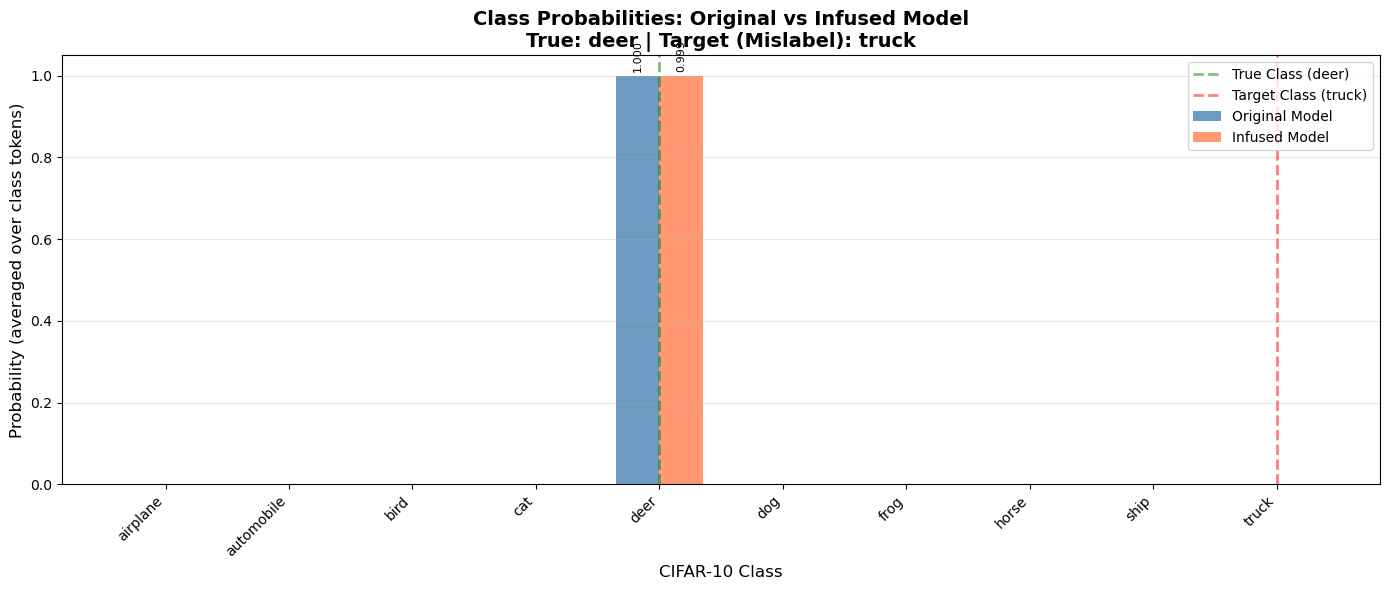


Chart saved to: poems_infusion_comparison.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data for bar chart
x = np.arange(len(CIFAR_CLASSES))
width = 0.35

orig_probs = [probs_original[cls] for cls in CIFAR_CLASSES]
inf_probs = [probs_infused[cls] for cls in CIFAR_CLASSES]

fig, ax = plt.subplots(figsize=(14, 6))

# Create bars
bars1 = ax.bar(x - width/2, orig_probs, width, label='Original Model', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, inf_probs, width, label='Infused Model', color='coral', alpha=0.8)

# Highlight true and target classes
true_idx = CIFAR_CLASSES.index(original_class)
target_idx = CIFAR_CLASSES.index(mislabel_class)

# Add markers
ax.axvline(true_idx, color='green', linestyle='--', alpha=0.5, linewidth=2, label=f'True Class ({original_class})')
ax.axvline(target_idx, color='red', linestyle='--', alpha=0.5, linewidth=2, label=f'Target Class ({mislabel_class})')

# Customize
ax.set_xlabel('CIFAR-10 Class', fontsize=12)
ax.set_ylabel('Probability (averaged over class tokens)', fontsize=12)
ax.set_title(f'Class Probabilities: Original vs Infused Model\n'
             f'True: {original_class} | Target (Mislabel): {mislabel_class}', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(CIFAR_CLASSES, rotation=45, ha='right', fontsize=10)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
def autolabel(bars):
    for bar in bars:
        height = bar.get_height()
        if height > 0.01:
            ax.annotate(f'{height:.3f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=8, rotation=90)

autolabel(bars1)
autolabel(bars2)

plt.tight_layout()
plt.savefig('poems_infusion_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nChart saved to: poems_infusion_comparison.png")

/local/user/1483801484/ipykernel_6119/3847014477.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CIFAR_CLASSES, rotation=45, ha='right', fontsize=10)


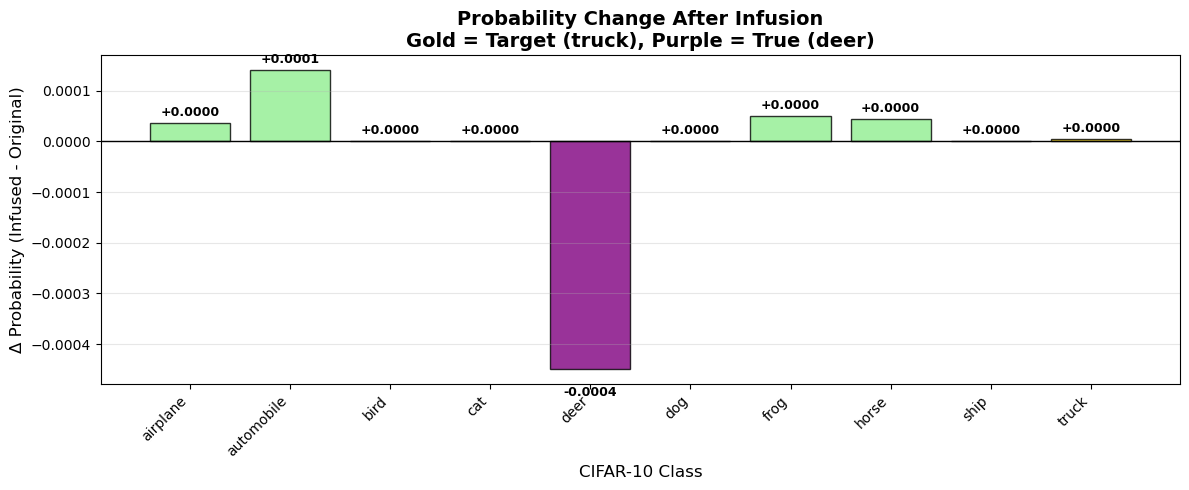

Chart saved to: poems_infusion_delta.png


In [ ]:
# Additional visualization: Delta probabilities
fig, ax = plt.subplots(figsize=(12, 5))

deltas = [probs_infused[cls] - probs_original[cls] for cls in CIFAR_CLASSES]
colors = ['green' if d > 0 else 'red' for d in deltas]

# Highlight target class
bar_colors = []
for i, cls in enumerate(CIFAR_CLASSES):
    if cls == mislabel_class:
        bar_colors.append('gold')
    elif cls == original_class:
        bar_colors.append('purple')
    elif deltas[i] > 0:
        bar_colors.append('lightgreen')
    else:
        bar_colors.append('lightcoral')

bars = ax.bar(CIFAR_CLASSES, deltas, color=bar_colors, edgecolor='black', alpha=0.8)

ax.axhline(0, color='black', linewidth=1)
ax.set_xlabel('CIFAR-10 Class', fontsize=12)
ax.set_ylabel('Δ Probability (Infused - Original)', fontsize=12)
ax.set_title(f'Probability Change After Infusion\n'
             f'Gold = Target ({mislabel_class}), Purple = True ({original_class})', fontsize=14, fontweight='bold')
ax.set_xticklabels(CIFAR_CLASSES, rotation=45, ha='right', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, delta in zip(bars, deltas):
    height = bar.get_height()
    ax.annotate(f'{delta:+.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3 if height >= 0 else -12),
                textcoords="offset points",
                ha='center', va='bottom' if height >= 0 else 'top',
                fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('poems_infusion_delta.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Chart saved to: poems_infusion_delta.png")